In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [5]:
df=pd.read_csv("dataset1.csv")

In [6]:
rawDataCopy=df

In [7]:
labels = rawDataCopy[['Output']]
features = rawDataCopy.drop('Output', axis=1)

In [8]:
transformedFeatures = features.apply(lambda x: np.log10(x) if np.issubdtype(x.dtype, np.number) else x)

NameError: name 'plt' is not defined

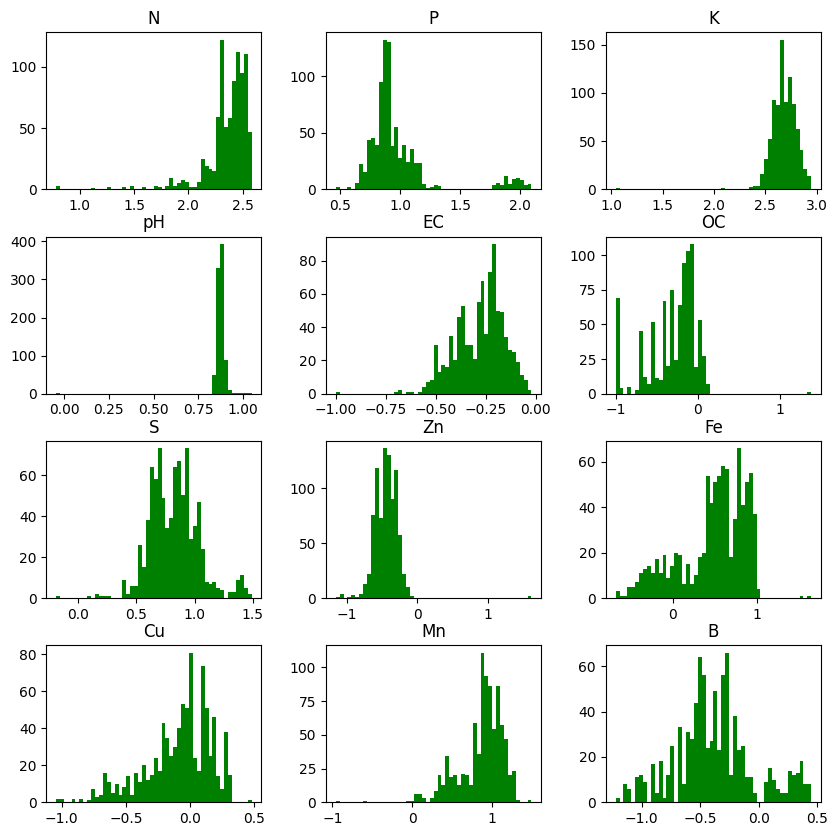

In [9]:
transformedFeatures.hist(bins=50, figsize=(10, 10), color='green', grid=False)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformedFeatures, labels, test_size = 0.2, shuffle=True, random_state = 42)

In [12]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),   # input: num_features
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax')  # multi-class output
])


In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4850 - loss: 0.8942 - val_accuracy: 0.5352 - val_loss: 0.8321
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5261 - loss: 0.8311 - val_accuracy: 0.5775 - val_loss: 0.8303
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5987 - loss: 0.8188 - val_accuracy: 0.6479 - val_loss: 0.8066
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6319 - loss: 0.8010 - val_accuracy: 0.7183 - val_loss: 0.7959
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6635 - loss: 0.7857 - val_accuracy: 0.6761 - val_loss: 0.7706
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6461 - loss: 0.7712 - val_accuracy: 0.6761 - val_loss: 0.7674
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6635 - loss: 0.7577 - val_accuracy: 0.6620 - val_loss: 0.7334
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6651 - loss: 0.7390 - val_accuracy: 0.7183 - val_loss:

In [15]:
loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {acc:.2f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6591 - loss: 0.7730 
✅ Test Accuracy: 0.66


In [19]:
sample = np.array([[138, 8.6, 560, 7.46, 0.62, 0.7, 5.9, 0.24, 0.31, 0.77, 8.71, 0.11]])

pred = model.predict(sample)
print("Raw prediction:", pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Raw prediction: [[1. 0. 0.]]


In [20]:
pred_class = np.argmax(pred, axis=1)
print("Predicted class:", pred_class)

Predicted class: [0]


In [21]:
model.save("soil_ann_model.h5")

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\pawar\AppData\Local\Temp\tmpi6g35b4k\assets


INFO:tensorflow:Assets written to: C:\Users\pawar\AppData\Local\Temp\tmpi6g35b4k\assets


Saved artifact at 'C:\Users\pawar\AppData\Local\Temp\tmpi6g35b4k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2211030946384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2211030947728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2211030947152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2211030946000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2211030948304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2211030946192: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [23]:
with open("soil_ann_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model converted and saved as soil_ann_model.tflite")

✅ Model converted and saved as soil_ann_model.tflite
